**Hello lovely reader!** In this tutorial/assignment, we'll be using the *Scrapy* Python library to webscrape [The Movie Database](https://www.themoviedb.org/?language=en-US){target="_blank"} in an attempt to get some show/movie recommendations depending on your favorite movie. Our idea is simple: if a movie has a bunch of the same actors as your favorite movie, it is likely a good recommendation. 

### Webscraping Actors and Movies

We'll get started by installing scrapy, then running in your terminal:

`scrapy startproject TMDB_scraper`

This will create a directory equipped with a bunch of machinery for running "spiders" which will crawl around the webpages' HTML code and parse it as we please. First, we'll navigate to the `/spiders` folder, and create a new .py file called `tmdb_spider.py`. This is where we will code our spider.

The **gameplan** to make for our spider follows three steps:
1. Start on the movie's webpage and navigate to its "Full Cast and Crew" page
2. Navigate to all the actors webpages on the cast page
3. Scrape the movies each actor was in and fill in the results in a CSV file

We'll begin by importing `scrapy` and other important things like `Spider` and `Request`. To create our spider, we'll define a `TmdbSpider` class that inherits from `scrapy.Spider`, so it is equipped with useful scrapy machinery.

Then, we need to provide our spider a unique `name`. We'll also define an initializer, so when we run our spider, we can provide in an argument for the subdirectory/favorite movie page we want our spider to start on. This will add the page url to `start_urls`, which will indicate for the spider to begin scraping this one first.

```python
from scrapy.spiders import Spider
from scrapy.http import Request
import scrapy

class TmdbSpider(scrapy.Spider):
    # Unique name!
    name = 'tmdb_spider'
    # Provide your favorite movie's subdirectory
    def __init__(self, subdir="", *args, **kwargs):
        self.start_urls = [f"https://www.themoviedb.org/movie/{subdir}/"]
        
```

Alright, so our spider is going to start with some movie page, but we also need to define a `parse` function which our spider will execute first on `start_urls`. Since the full cast and crew webpage can be found by simply appending `/cast` to the end of the url, we'll do that. 

From there, we'll send in a GET request using `Request()` to that new url, which will return another response object for us to parse. The function provided in the `callback` argument, `parse_full_credits`, instructs the spider how to parse this new response. We'll define that next.

```python       
def parse(self, response):
    '''
    Assumes spider starts on a movie webpage, 
    navigates to the "Full Cast & Crew" page,
    then runs parse_full_credits.
    '''
    cast_url = response.url + '/cast'
    yield Request(cast_url, callback = self.parse_full_credits)
```

Ok, now our spider is on the full_cast and crew page. It needs to find all the links to the actors pages from the html in `response.body`. Some digging around on the html code for these webpages reveals that the people links can be found under `ol` tags with `class="people_credits"`. But these tags include lists for actors, crew members, production, etc., so to just get the list of actors, we'll index out the first list. 

From there, we'll parse the html further by finding all `a` tags embedded in `p` tags within the frist `ol.people.credits` tag (for actors), which contain the hyperlinks to the actors webpages. For each one, we'll get the `href` attribute, and join it with the base url `https://www.themoviedb.org/` which will give us the full url for the actor's webpage.

Then, following the gameplan, we'll then send another GET request to each one of the actor's pages, and pass in `parse_actor_page` to tell our spider how to parse the response we receive back. We'll define that next.

```python
    def parse_full_credits(self, response):
        '''
        Assumes spider starts on a cast webpage, 
        navigates to each actors page, 
        then calls parse_actor_page.
        '''
        # Getting the urls to all actors pages
        actors = response.css('ol.people.credits')[0].css('p a')
        actor_urls = [response.urljoin(actor.attrib['href']) for actor in actors]
        for url in actor_urls:
            yield Request(url, callback = self.parse_actor_page)

```

Right, so now our spider is now simultaneously crawling over all the actors webpages. First, we'll get the actor's full name, which can be found in the `h2` tags with `class="title"`. We'll CSS select just the text within the `a` tag, and assign the resulting string to `actor_name`.

Next, we want to get the movies the actor has *acted* in. Unfortunately, the tables on the webpages can come in many different orders, sometimes starting with the "Acting" table, but other times, starting with "Crew" or "Production". Fortunately, we can get the position of the "Acting" table with a little more CSS selecting. All of these tables will be in the `div.credits_list` tag, and each will have a header `h3` tag, containing text for which table it holds. We'll get these names one by one, and assign them to a list `table_names`. Then, within `table_names`, we'll get just the index of the element `"Acting"`, which will tell us the position the "Acting" table is in.

Finally, using that index, we can select the right `table.card.credits` tag, containing the "Acting" table. Within these tables, there are a lot of dividers, but ultimately, all of the title names are stored within `bdi` tags. For each one, we'll:
- Access the text within them
- Check if there's a repeat (using a running set of title names)
- If not, yield a dictionary with `actor_name` and `movie_or_TV_name` values for inputting into a CSV file

```python
    def parse_actor_page(self, response):
        '''
        Assumes spider starts on an actor's page, 
        then yields rows for a csv file containing 
        the actor's name and movies they have performed in.
        '''
        # Scraping actor name
        actor_name = response.css('h2.title a::text').get()
        
        # Getting the right table number for "Acting"
        table_names = [table.css('::text').get() for table in response.css('div.credits_list h3')]
        table_num = [i for i in range(len(table_names)) if table_names[i] == "Acting"][0]
        
        # Scraping all titles, assigning to actor
        titles = set()
        for title in response.css('table.card.credits')[table_num].css('bdi'):
            movie_or_TV_name = title.css('::text').get()
            # Making sure no duplicate titles
            if movie_or_TV_name not in titles:
                titles.add(movie_or_TV_name)
                yield {
                    "actor": actor_name,
                    "movie_or_TV_name": movie_or_TV_name
                }
```

Together, our completed `tmdb_spider.py` file should look something like this:

```python
from scrapy.spiders import Spider
from scrapy.http import Request
import scrapy

class TmdbSpider(scrapy.Spider):
    # Unique name!
    name = 'tmdb_spider'
    # Provide your favorite movie's subdirectory
    def __init__(self, subdir="", *args, **kwargs):
        self.start_urls = [f"https://www.themoviedb.org/movie/{subdir}/"]
        
    def parse(self, response):
        '''
        Assumes spider starts on a movie webpage, navigates to the "Full Cast & Crew" page,
        then runs parse_full_credits.
        '''
        cast_url = response.url + '/cast'
        yield Request(cast_url, callback = self.parse_full_credits)
        
    def parse_full_credits(self, response):
        '''
        Assumes spider starts on a cast webpage, navigates to each actors page and calls parse_actor_page.
        '''
        # Getting the urls to all actors pages
        actors = response.css('ol.people.credits')[0].css('p a')
        actor_urls = [response.urljoin(actor.attrib['href']) for actor in actors]
        for url in actor_urls:
            yield Request(url, callback = self.parse_actor_page)
        
    def parse_actor_page(self, response):
        '''
        Assumes spider starts on an actor's page, and yields rows for a csv file containing the actor's name
        and a movie they have performed in.
        '''
        # Scraping actor name
        actor_name = response.css('h2.title a::text').get()
        
        # Getting the right table number for "Acting"
        table_names = [table.css('::text').get() for table in response.css('div.credits_list h3')]
        table_num = [i for i in range(len(table_names)) if table_names[i] == "Acting"][0]
        
        # Scraping all titles, assigning to actor
        titles = set()
        for title in response.css('table.card.credits')[table_num].css('bdi'):
            movie_or_TV_name = title.css('::text').get()
            # Making sure no duplicate titles
            if movie_or_TV_name not in titles:
                titles.add(movie_or_TV_name)
                yield {
                    "actor": actor_name,
                    "movie_or_TV_name": movie_or_TV_name
                }
```

Then, to actually run this spider (or "crawl"), navigate to the `TMBD_scraper` directory in the command terminal and type in:

`scrapy crawl tmdb_spider -o results.csv -a subdir=671-harry-potter-and-the-philosopher-s-stone`

where `subdir=` can be filled in with your favorite movie (in this case, we've put in Harry Potter and the Philosopher's Stone). This will yield a CSV file with an `actor` and `movie_or_TV_name` column, as we yielded in `parse_actor_page`. I've run this spider below and displayed the results in a pandas DataFrame.

In [55]:
import pandas as pd
results = pd.read_csv("results.csv")
results

,actor,movie_or_TV_name
0,Paul Marc Davis,Arthur & Merlin: Knights of Camelot
1,Paul Marc Davis,Class
2,Paul Marc Davis,Son of God
3,Paul Marc Davis,The Bible
4,Paul Marc Davis,The Sky in Bloom
...,...,...
3076,Richard Griffiths,The Sweeney
3077,Richard Griffiths,Norma
3078,Richard Griffiths,Village Hall
3079,Richard Griffiths,Crown Court


Great, we've completed the webscraping portion. Now, we let's see what we can do with this data to make some recommendations.

### Making Recommendations

Alright, we want to group the movies/TV names and count the number of actors from our favorite movie that were featured in it. We can do this with the groupby function, then applying the `count` function to count the number of actors within each movie group.

Then, we'll sort by `'Number of Shared Actors'`, and return the top 10 movies with the most shared actors, which we assume to be pretty decent recommendations based on your favorite movie.

In [56]:
recs = results.groupby('movie_or_TV_name').apply('count').rename(columns={'actor':'Number of Shared Actors'})
recs = recs.sort_values(by='Number of Shared Actors', ascending=False)
recs.reset_index(inplace=True)
recs.head(10)

,movie_or_TV_name,Number of Shared Actors
0,Harry Potter and the Philosopher's Stone,62
1,Harry Potter and the Chamber of Secrets,37
2,Harry Potter and the Prisoner of Azkaban,26
3,Harry Potter and the Order of the Phoenix,24
4,Harry Potter and the Deathly Hallows: Part 2,23
5,Harry Potter and the Deathly Hallows: Part 1,20
6,Harry Potter and the Half-Blood Prince,19
7,Harry Potter and the Goblet of Fire,19
8,Doctor Who,13
9,Harry Potter 20th Anniversary: Return to Hogwarts,11


Alright, as expected, using "Harry Potter" as our favorite movie returned the rest of the movies in the Harry Potter franchise, as they would share the most actors. That's not to say our recommendation assumption was wrong, if one hadn't seen the rest of the movies before, these would arguably be the best recommendations. However, a more nuanced recommendation model could take into account many other different factors that simply your "favorite movie" to determine the best one to watch. 

Nevertheless, let's see if we can visualize these results in an appealing way to see the top recommendations in terms of shared actors. We can first make a simple bar chart ranking movies based on Shared Actors. It will display larger bars on top, so people can easily see movies that share a lot of the same actors.

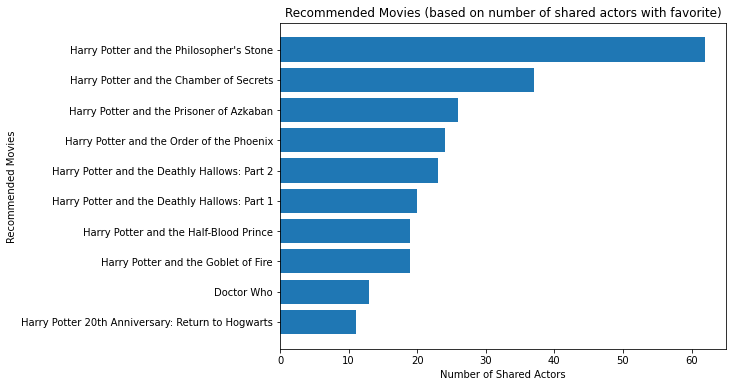

In [57]:
from matplotlib import pyplot as plt

top_recs = recs[9::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_recs['movie_or_TV_name'], top_recs['Number of Shared Actors'])
plt.title('Recommended Movies (based on number of shared actors with favorite)')
plt.xlabel('Number of Shared Actors')
plt.ylabel('Recommended Movies')
plt.show()

We can also use the original actor-movie DataFrame to construct a crazy parallel categories plot using Plotly, showing how each actors association with each movie. Of course, this plot gets complicated fast, so we'll limit it by first sorting the actor-movie pairs, ranking `results` by the number of shared actors in the movie, and then only plot the first 150 rows. This is more so a visualization to demonstrate the interconnectedness of actors and movies, rather than something for a user to utilize for recommendations :).

In [58]:
count = results.groupby('movie_or_TV_name').transform('count')
results['count'] = count
results = results.sort_values(by='count', ascending=False)

In [62]:
from plotly import express as px
import plotly.io as pio
pio.renderers.default="iframe"

fig = px.parallel_categories(results[:150],
                             dimensions = ["actor", "movie_or_TV_name"],
                             height = 1000)
fig.update_layout(margin={"r":100,"t":0,"l":100,"b":0})
fig.show()

And that's it! As we've seen, using webscraping tools like scrapy can make gathering data implicitly stored on webpages and online databases nice and manageable, and we can use it for cool applications (such as recommendation systems like this assignment). 